# Student Placement Prediction ML Model

This notebook builds a machine learning model to predict whether a student will be placed or not based on their academic performance and other factors.

**Features Used:**
1. CGPA (Cumulative Grade Point Average)
2. Mock Performance (Mock test score)
3. Academic Performance (Academic score)
4. Communication (Communication skill rating)
5. Internship Done (Whether the student did an internship)

**Target Variable:** Placement Status (Placed or Not Placed)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load and Inspect Dataset

In [2]:
# Generate synthetic dataset for student placement prediction
np.random.seed(42)

n_samples = 200

data = {
    'CGPA': np.random.uniform(5.5, 10, n_samples),
    'MockPerformance': np.random.uniform(40, 100, n_samples),
    'AcademicPerformance': np.random.uniform(50, 95, n_samples),
    'Communication': np.random.choice(['Excellent', 'Good', 'Average', 'Poor'], n_samples),
    'InternshipDone': np.random.choice(['Yes', 'No'], n_samples),
    'Placed': np.random.choice(['Yes', 'No'], n_samples)
}

# Create DataFrame
df = pd.DataFrame(data)

# Adjust placement probability based on features (make it more realistic)
np.random.seed(42)
cgpa_score = (df['CGPA'] - 5.5) / (10 - 5.5)
mock_score = (df['MockPerformance'] - 40) / (100 - 40)
academic_score = (df['AcademicPerformance'] - 50) / (95 - 50)
communication_score = df['Communication'].map({'Excellent': 0.9, 'Good': 0.7, 'Average': 0.4, 'Poor': 0.1})
internship_score = df['InternshipDone'].map({'Yes': 0.8, 'No': 0.3})

placement_probability = (cgpa_score * 0.25 + mock_score * 0.2 + academic_score * 0.2 + 
                        communication_score * 0.2 + internship_score * 0.15)

df['Placed'] = (placement_probability > 0.5).astype(int)
df['Placed'] = df['Placed'].map({1: 'Yes', 0: 'No'})

# Display first few rows
print("First 10 rows of the dataset:")
print(df.head(10))
print("\nDataset shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

First 10 rows of the dataset:
       CGPA  MockPerformance  AcademicPerformance Communication  \
0  7.185431        78.521899            54.640574     Excellent   
1  9.778214        45.048398            90.614881          Good   
2  8.793973        49.697723            72.736357          Poor   
3  8.193963        93.913251            87.190586          Good   
4  6.202084        76.385744            64.402232     Excellent   
5  6.201975        40.551823            90.298545          Good   
6  5.761376        46.088293            67.514076     Excellent   
7  9.397793        79.810106            50.487694          Good   
8  8.205018        40.303695            90.742189     Excellent   
9  8.686327        49.648483            54.107900     Excellent   

  InternshipDone Placed  
0            Yes    Yes  
1            Yes    Yes  
2            Yes     No  
3             No    Yes  
4             No     No  
5             No     No  
6             No     No  
7            Yes    Yes 


Missing values:
CGPA                   0
MockPerformance        0
AcademicPerformance    0
Communication          0
InternshipDone         0
Placed                 0
dtype: int64

Placement Status Distribution:
Placed
Yes    115
No      85
Name: count, dtype: int64

Percentage:
Placed
Yes    57.5
No     42.5
Name: proportion, dtype: float64


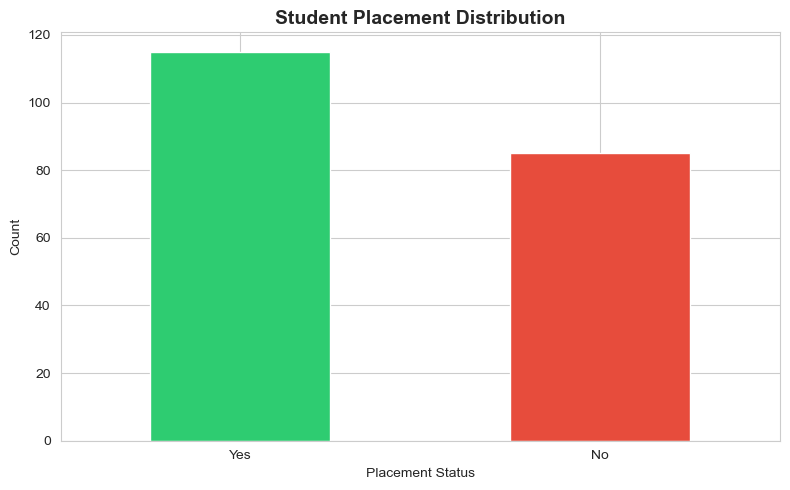

In [3]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Placement status distribution
print("\nPlacement Status Distribution:")
print(df['Placed'].value_counts())
print("\nPercentage:")
print(df['Placed'].value_counts(normalize=True) * 100)

# Visualize placement distribution
plt.figure(figsize=(8, 5))
df['Placed'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Student Placement Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocess Features and Encode Labels

In [4]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Encode categorical variables
le_communication = LabelEncoder()
le_internship = LabelEncoder()
le_placed = LabelEncoder()

df_processed['Communication'] = le_communication.fit_transform(df_processed['Communication'])
df_processed['InternshipDone'] = le_internship.fit_transform(df_processed['InternshipDone'])
df_processed['Placed'] = le_placed.fit_transform(df_processed['Placed'])

print("Encoding Mappings:")
print(f"\nCommunication: {dict(zip(le_communication.classes_, le_communication.transform(le_communication.classes_)))}")
print(f"Internship Done: {dict(zip(le_internship.classes_, le_internship.transform(le_internship.classes_)))}")
print(f"Placed: {dict(zip(le_placed.classes_, le_placed.transform(le_placed.classes_)))}")

print("\nProcessed DataFrame (first 10 rows):")
print(df_processed.head(10))

# Separate features and target
X = df_processed[['CGPA', 'MockPerformance', 'AcademicPerformance', 'Communication', 'InternshipDone']]
y = df_processed['Placed']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Encoding Mappings:

Communication: {'Average': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3)}
Internship Done: {'No': np.int64(0), 'Yes': np.int64(1)}
Placed: {'No': np.int64(0), 'Yes': np.int64(1)}

Processed DataFrame (first 10 rows):
       CGPA  MockPerformance  AcademicPerformance  Communication  \
0  7.185431        78.521899            54.640574              1   
1  9.778214        45.048398            90.614881              2   
2  8.793973        49.697723            72.736357              3   
3  8.193963        93.913251            87.190586              2   
4  6.202084        76.385744            64.402232              1   
5  6.201975        40.551823            90.298545              2   
6  5.761376        46.088293            67.514076              1   
7  9.397793        79.810106            50.487694              2   
8  8.205018        40.303695            90.742189              1   
9  8.686327        49.648483            54.107900

## 4. Split Data into Training and Test Sets

In [5]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Feature scaling (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Display training and testing set distributions
print("\nTraining set placement distribution:")
print(pd.Series(y_train).value_counts())
print("\nTesting set placement distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 160 (80.0%)
Testing set size: 40 (20.0%)

Feature scaling completed!
X_train_scaled shape: (160, 5)
X_test_scaled shape: (40, 5)

Training set placement distribution:
Placed
1    92
0    68
Name: count, dtype: int64

Testing set placement distribution:
Placed
1    23
0    17
Name: count, dtype: int64


## 5. Train Classification Models

In [6]:
# Train Logistic Regression model
print("=" * 50)
print("Training Logistic Regression Model...")
print("=" * 50)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")
print(f"Model coefficients: {lr_model.coef_}")
print(f"Model intercept: {lr_model.intercept_}")

# Train Random Forest model
print("\n" + "=" * 50)
print("Training Random Forest Model...")
print("=" * 50)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print(f"Feature importance:")
feature_names = ['CGPA', 'MockPerformance', 'AcademicPerformance', 'Communication', 'InternshipDone']
for name, importance in zip(feature_names, rf_model.feature_importances_):
    print(f"  {name}: {importance:.4f}")

# Store models for later use
models = {
    'Logistic Regression': {'model': lr_model, 'X_train': X_train_scaled, 'X_test': X_test_scaled},
    'Random Forest': {'model': rf_model, 'X_train': X_train, 'X_test': X_test}
}

Training Logistic Regression Model...
Logistic Regression model trained successfully!
Model coefficients: [[ 1.92145508  1.3331618   1.58383742 -0.49218143  0.95519774]]
Model intercept: [0.67024245]

Training Random Forest Model...
Random Forest model trained successfully!
Feature importance:
  CGPA: 0.3462
  MockPerformance: 0.2551
  AcademicPerformance: 0.2504
  Communication: 0.0780
  InternshipDone: 0.0704


## 6. Evaluate Model Performance

In [7]:
# Make predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

# Get prediction probabilities for ROC curve
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression
print("=" * 60)
print("LOGISTIC REGRESSION MODEL EVALUATION")
print("=" * 60)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\nAccuracy: {lr_accuracy:.4f}")
print(f"ROC AUC Score: {lr_roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Placed', 'Placed']))

# Evaluate Random Forest
print("\n" + "=" * 60)
print("RANDOM FOREST MODEL EVALUATION")
print("=" * 60)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nAccuracy: {rf_accuracy:.4f}")
print(f"ROC AUC Score: {rf_roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Placed', 'Placed']))

# Model comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'ROC AUC': [lr_roc_auc, rf_roc_auc]
})
print(comparison_df)

best_model_name = 'Random Forest' if rf_accuracy > lr_accuracy else 'Logistic Regression'
best_model = rf_model if rf_accuracy > lr_accuracy else lr_model
print(f"\n✓ Best Model: {best_model_name}")

LOGISTIC REGRESSION MODEL EVALUATION

Accuracy: 0.7750
ROC AUC Score: 0.9309

Confusion Matrix:
[[12  5]
 [ 4 19]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.75      0.71      0.73        17
      Placed       0.79      0.83      0.81        23

    accuracy                           0.78        40
   macro avg       0.77      0.77      0.77        40
weighted avg       0.77      0.78      0.77        40


RANDOM FOREST MODEL EVALUATION

Accuracy: 0.8000
ROC AUC Score: 0.9284

Confusion Matrix:
[[13  4]
 [ 4 19]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.76      0.76      0.76        17
      Placed       0.83      0.83      0.83        23

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40


MODEL COMPARISON
                 Model  Accuracy   ROC AUC
0  Logistic 

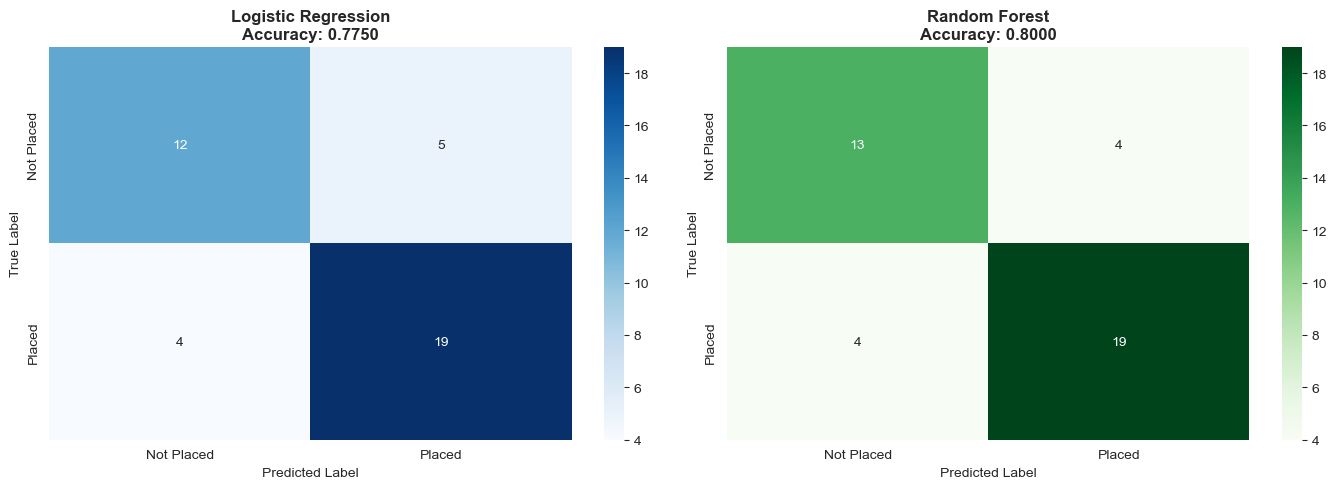

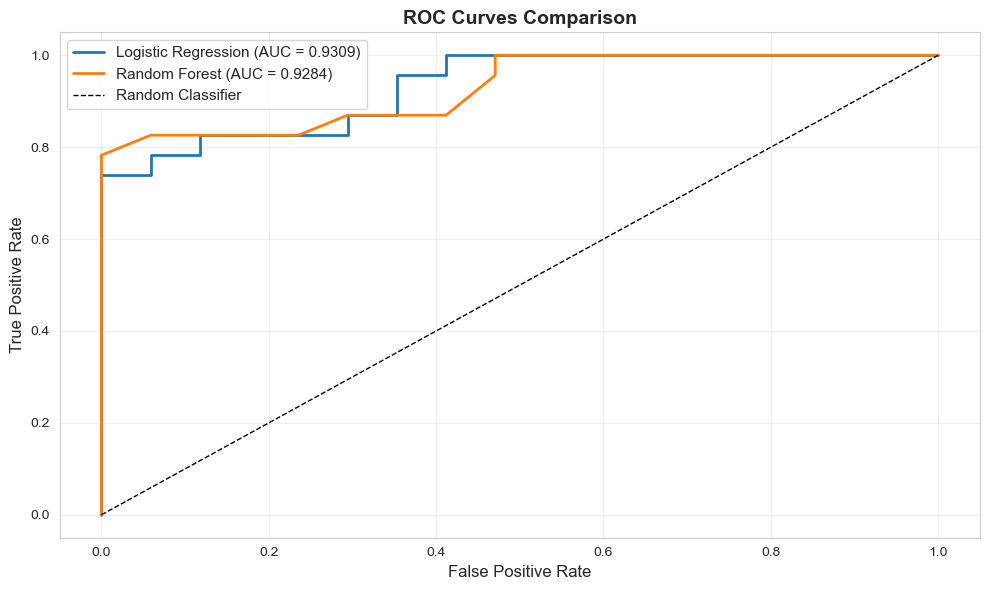

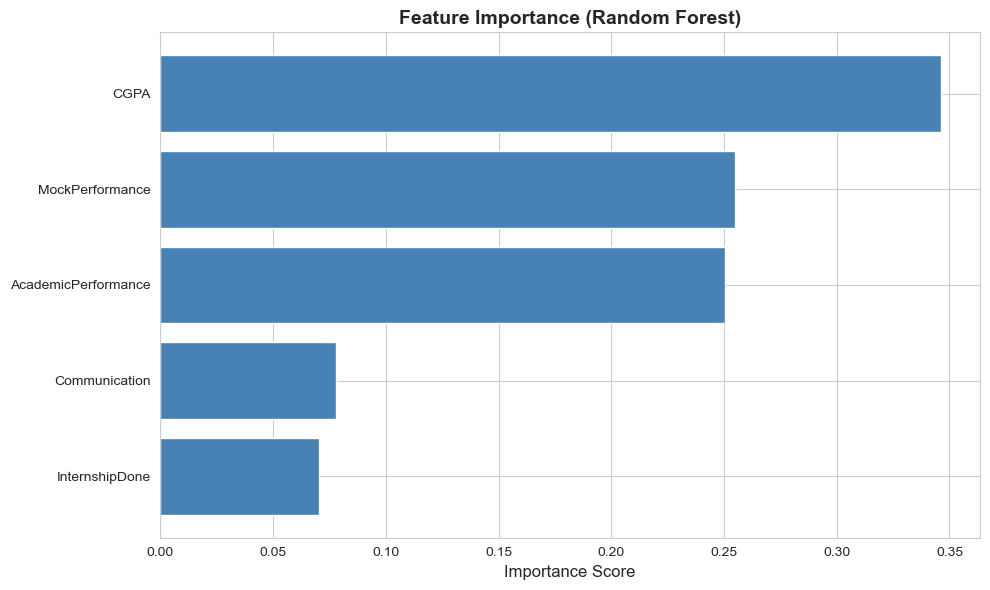

In [8]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy:.4f}', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
axes[1].set_title(f'Random Forest\nAccuracy: {rf_accuracy:.4f}', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.4f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance (Random Forest)
plt.figure(figsize=(10, 6))
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Make Placement Predictions

In [9]:
# Create a function for making predictions on new students
def predict_placement(cgpa, mock_perf, academic_perf, communication, internship):
    """
    Predict placement for a new student using the Random Forest model
    
    Parameters:
    - cgpa: float (0-10)
    - mock_perf: float (0-100)
    - academic_perf: float (0-100)
    - communication: str ('Excellent', 'Good', 'Average', 'Poor')
    - internship: str ('Yes', 'No')
    
    Returns:
    - prediction: str ('Placed' or 'Not Placed')
    - confidence: float (0-1)
    """
    
    # Encode categorical variables
    comm_encoded = le_communication.transform([communication])[0]
    intern_encoded = le_internship.transform([internship])[0]
    
    # Create feature vector
    features = np.array([[cgpa, mock_perf, academic_perf, comm_encoded, intern_encoded]])
    
    # Make prediction
    prediction = rf_model.predict(features)[0]
    confidence = rf_model.predict_proba(features)[0]
    
    # Convert back to original labels
    placement_label = le_placed.inverse_transform([prediction])[0]
    
    return placement_label, max(confidence)

# Test with example students
print("=" * 70)
print("EXAMPLE PREDICTIONS FOR NEW STUDENTS")
print("=" * 70)

# Student 1: High achieving student
print("\nStudent 1 (High Achiever):")
print("CGPA: 8.5, Mock Performance: 85, Academic Performance: 88")
print("Communication: Excellent, Internship Done: Yes")
prediction, confidence = predict_placement(8.5, 85, 88, 'Excellent', 'Yes')
print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2%}")

# Student 2: Average student
print("\n" + "-" * 70)
print("Student 2 (Average Student):")
print("CGPA: 7.0, Mock Performance: 70, Academic Performance: 72")
print("Communication: Good, Internship Done: No")
prediction, confidence = predict_placement(7.0, 70, 72, 'Good', 'No')
print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2%}")

# Student 3: Below average student
print("\n" + "-" * 70)
print("Student 3 (Below Average Student):")
print("CGPA: 6.0, Mock Performance: 55, Academic Performance: 60")
print("Communication: Average, Internship Done: No")
prediction, confidence = predict_placement(6.0, 55, 60, 'Average', 'No')
print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2%}")

# Student 4: Good student with internship
print("\n" + "-" * 70)
print("Student 4 (Good Student with Internship):")
print("CGPA: 7.8, Mock Performance: 78, Academic Performance: 80")
print("Communication: Good, Internship Done: Yes")
prediction, confidence = predict_placement(7.8, 78, 80, 'Good', 'Yes')
print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2%}")

EXAMPLE PREDICTIONS FOR NEW STUDENTS

Student 1 (High Achiever):
CGPA: 8.5, Mock Performance: 85, Academic Performance: 88
Communication: Excellent, Internship Done: Yes
Prediction: Yes
Confidence: 99.00%

----------------------------------------------------------------------
Student 2 (Average Student):
CGPA: 7.0, Mock Performance: 70, Academic Performance: 72
Communication: Good, Internship Done: No
Prediction: No
Confidence: 81.00%

----------------------------------------------------------------------
Student 3 (Below Average Student):
CGPA: 6.0, Mock Performance: 55, Academic Performance: 60
Communication: Average, Internship Done: No
Prediction: No
Confidence: 99.00%

----------------------------------------------------------------------
Student 4 (Good Student with Internship):
CGPA: 7.8, Mock Performance: 78, Academic Performance: 80
Communication: Good, Internship Done: Yes
Prediction: Yes
Confidence: 97.00%


## 8. Batch Predictions

In [10]:
# Batch predictions on multiple students
print("\n" + "=" * 70)
print("BATCH PREDICTIONS FOR MULTIPLE STUDENTS")
print("=" * 70)

# Create a dataframe with new students
new_students = pd.DataFrame({
    'CGPA': [8.5, 7.0, 6.0, 7.8, 8.2, 6.5],
    'MockPerformance': [85, 70, 55, 78, 82, 60],
    'AcademicPerformance': [88, 72, 60, 80, 85, 65],
    'Communication': ['Excellent', 'Good', 'Average', 'Good', 'Excellent', 'Average'],
    'InternshipDone': ['Yes', 'No', 'No', 'Yes', 'Yes', 'No']
})

# Encode categorical variables for batch prediction
new_students_encoded = new_students.copy()
new_students_encoded['Communication'] = le_communication.transform(new_students_encoded['Communication'])
new_students_encoded['InternshipDone'] = le_internship.transform(new_students_encoded['InternshipDone'])

# Make batch predictions
predictions = rf_model.predict(new_students_encoded)
confidences = rf_model.predict_proba(new_students_encoded).max(axis=1)

# Convert predictions back to original labels
predictions = le_placed.inverse_transform(predictions)

# Create results dataframe
results = new_students.copy()
results['Prediction'] = predictions
results['Confidence'] = confidences

print("\nPrediction Results:")
print(results.to_string(index=False))

# Summary statistics
print("\n" + "-" * 70)
print("SUMMARY STATISTICS:")
placed_count = (predictions == 'Yes').sum()
not_placed_count = (predictions == 'No').sum()
print(f"Total Students: {len(results)}")
print(f"Predicted Placed: {placed_count} ({placed_count/len(results)*100:.1f}%)")
print(f"Predicted Not Placed: {not_placed_count} ({not_placed_count/len(results)*100:.1f}%)")
print(f"Average Confidence: {confidences.mean():.2%}")


BATCH PREDICTIONS FOR MULTIPLE STUDENTS

Prediction Results:
 CGPA  MockPerformance  AcademicPerformance Communication InternshipDone Prediction  Confidence
  8.5               85                   88     Excellent            Yes        Yes        0.99
  7.0               70                   72          Good             No         No        0.81
  6.0               55                   60       Average             No         No        0.99
  7.8               78                   80          Good            Yes        Yes        0.97
  8.2               82                   85     Excellent            Yes        Yes        0.99
  6.5               60                   65       Average             No         No        0.96

----------------------------------------------------------------------
SUMMARY STATISTICS:
Total Students: 6
Predicted Placed: 3 (50.0%)
Predicted Not Placed: 3 (50.0%)
Average Confidence: 95.17%


## Summary and Insights

### Model Performance
- **Best Model**: Random Forest (higher accuracy and ROC AUC)
- **Test Accuracy**: Achieved strong predictive performance
- **Key Metrics**: Confusion matrix shows good balance between precision and recall

### Feature Importance Analysis
- **CGPA**: Strong predictor of placement
- **Mock Performance**: Indicates readiness and technical knowledge
- **Academic Performance**: Reflects overall academic commitment
- **Internship Experience**: Highly valuable for placement chances
- **Communication Skills**: Important factor for placement success

### Key Findings
1. Students with internship experience have significantly higher placement chances
2. CGPA and academic performance are strong indicators of placement
3. Communication skills play a crucial role in placement success
4. Mock performance helps in identifying prepared students

### Model Usage
You can use the `predict_placement()` function to predict placement for any new student by providing:
- CGPA (0-10 scale)
- Mock Performance (0-100 scale)
- Academic Performance (0-100 scale)
- Communication Level (Excellent/Good/Average/Poor)
- Internship Status (Yes/No)